In [30]:
import os
import pandas as pd
import ta
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define the path to the downloads folder
downloads_path = '../../downloads'

# List of stock tickers
stock_list = [
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', 'CRM', 'ORCL',
    'JNJ', 'PFE', 'MRK', 'ABT', 'BMY', 'TMO',
    'JPM', 'BAC', 'GS', 'MS', 'C', 'WFC',
    'AMZN', 'TSLA', 'NKE', 'HD', 'MCD', 'BKNG',
    'PG', 'KO', 'PEP', 'WMT', 'COST', 'KHC',
    'XOM', 'CVX', 'SLB', 'COP', 'PSX', 'MPC',
    'BA', 'HON', 'MMM', 'CAT', 'GE', 'DE',
    'VZ', 'T', 'CMCSA', 'TMUS', 'CHTR',
    'AMT', 'SPG', 'EQIX', 'O', 'CCI'
]

# Function to load data
def load_stock_data(ticker, directory):
    data = {}

    # Load historical data
    historical_file_path = os.path.join(directory, f"{ticker}_historical.csv")
    if os.path.exists(historical_file_path):
        data['historical'] = pd.read_csv(historical_file_path, parse_dates=['Date'], index_col='Date')

    # Load balance sheet data
    balance_sheet_file_path = os.path.join(directory, f"{ticker}_balance_sheet.csv")
    if os.path.exists(balance_sheet_file_path):
        data['income_statement'] = pd.read_csv(balance_sheet_file_path)

    # Load income statement data
    income_statement_file_path = os.path.join(directory, f"{ticker}_income_statement.csv")
    if os.path.exists(income_statement_file_path):
        data['income_statement'] = pd.read_csv(income_statement_file_path)

    # Load cash flow data
    cash_flow_file_path = os.path.join(directory, f"{ticker}_cash_flow.csv")
    if os.path.exists(income_statement_file_path):
        data['income_statement'] = pd.read_csv(income_statement_file_path)

    # Load additional data
    additional_data_file_path = os.path.join(directory, f"{ticker}_additional_data.csv")
    if os.path.exists(additional_data_file_path):
        data["additional_data"] = pd.read_csv(additional_data_file_path)

    return data

# Load all stock data into a dictionary of DataFrames
all_stock_data = {ticker: load_stock_data(ticker, downloads_path) for ticker in stock_list}

# Example: Display the first few rows of the AAPL DataFrame
aapl_data = all_stock_data['AAPL']['historical']
print(aapl_data.head())


                                Open       High        Low      Close  \
Date                                                                    
2014-06-26 00:00:00-04:00  19.983856  20.134227  19.857810  20.101057   
2014-06-27 00:00:00-04:00  20.083375  20.344313  20.072318  20.339891   
2014-06-30 00:00:00-04:00  20.366423  20.726873  20.364212  20.549965   
2014-07-01 00:00:00-04:00  20.680437  20.802061  20.594195  20.680437   
2014-07-02 00:00:00-04:00  20.757837  20.799851  20.585351  20.671595   

                              Volume  Dividends  Stock Splits  
Date                                                           
2014-06-26 00:00:00-04:00  130516000        0.0           0.0  
2014-06-27 00:00:00-04:00  256116000        0.0           0.0  
2014-06-30 00:00:00-04:00  197929200        0.0           0.0  
2014-07-01 00:00:00-04:00  152892000        0.0           0.0  
2014-07-02 00:00:00-04:00  113860000        0.0           0.0  


In [31]:
# Example: Display the first few rows of the AAPL balance sheet data
aapl_balance_sheet = all_stock_data['AAPL']['balance_sheet']
print(aapl_balance_sheet.head())

KeyError: 'balance_sheet'

In [ ]:
def preprocess_data(df):
    # Handle Missing Values
    df = df.dropna()

    # Feature Engineering: Adding moving averages
    df['20-Day MA'] = df['Close'].rolling(window=20).mean()
    df['50-Day MA'] = df['Close'].rolling(window=50).mean()
    df['200-Day MA'] = df['Close'].rolling(window=200).mean()

    # Feature Engineering: Adding moving averages for volume
    df['20-Day Volume MA'] = df['Volume'].rolling(window=20).mean()
    df['50-Day Volume MA'] = df['Volume'].rolling(window=50).mean()
    df['200-Day Volume MA'] = df['Volume'].rolling(window=200).mean()

    # Additional Technical Indicators
    df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    df['MACD'] = ta.trend.macd_diff(df['Close'])
    df['Bollinger High'] = ta.volatility.bollinger_hband(df['Close'])
    df['Bollinger Low'] = ta.volatility.bollinger_lband(df['Close'])

    # Dropping rows with NaN values
    df = df.dropna()

    return df

# Apply preprocessing to all stock data
preprocessed_data = {ticker: preprocess_data(df) for ticker, df in all_stock_data.items()}

# Example: Display the first few rows of the preprocesses AAPL DataFrame
preprocessed_aapl_data = preprocessed_data['AAPL']
print(preprocessed_aapl_data.head())

                                Open       High        Low      Close  \
Date                                                                    
2015-04-10 00:00:00-04:00  28.222660  28.504999  28.068047  28.480350   
2015-04-13 00:00:00-04:00  28.764920  28.809739  28.370544  28.424322   
2015-04-14 00:00:00-04:00  28.457941  28.522923  28.213696  28.301086   
2015-04-15 00:00:00-04:00  28.325732  28.487067  28.236100  28.408640   
2015-04-16 00:00:00-04:00  28.296600  28.480345  28.258508  28.271952   

                              Volume  Dividends  Stock Splits  20-Day MA  \
Date                                                                       
2015-04-10 00:00:00-04:00  160752000        0.0           0.0  28.180195   
2015-04-13 00:00:00-04:00  145460400        0.0           0.0  28.216719   
2015-04-14 00:00:00-04:00  102098400        0.0           0.0  28.231844   
2015-04-15 00:00:00-04:00  115881600        0.0           0.0  28.228931   
2015-04-16 00:00:00-04:00  11347

In [ ]:
# Verifying data types and summary stats
print(preprocessed_aapl_data.info())
print(preprocessed_aapl_data.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 2317 entries, 2015-04-10 00:00:00-04:00 to 2024-06-24 00:00:00-04:00
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Open               2317 non-null   float64
 1   High               2317 non-null   float64
 2   Low                2317 non-null   float64
 3   Close              2317 non-null   float64
 4   Volume             2317 non-null   int64  
 5   Dividends          2317 non-null   float64
 6   Stock Splits       2317 non-null   float64
 7   20-Day MA          2317 non-null   float64
 8   50-Day MA          2317 non-null   float64
 9   200-Day MA         2317 non-null   float64
 10  20-Day Volume MA   2317 non-null   float64
 11  50-Day Volume MA   2317 non-null   float64
 12  200-Day Volume MA  2317 non-null   float64
 13  EMA_20             2317 non-null   float64
 14  RSI                2317 non-null   float64
 15  MACD               2317 non-null

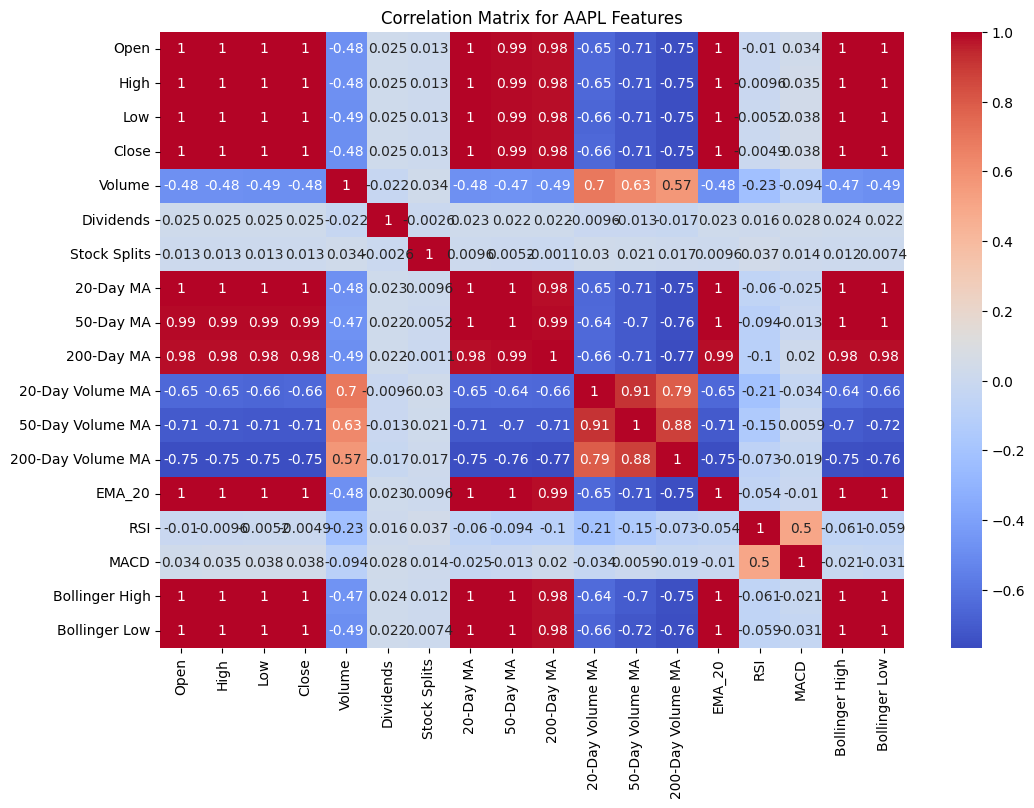

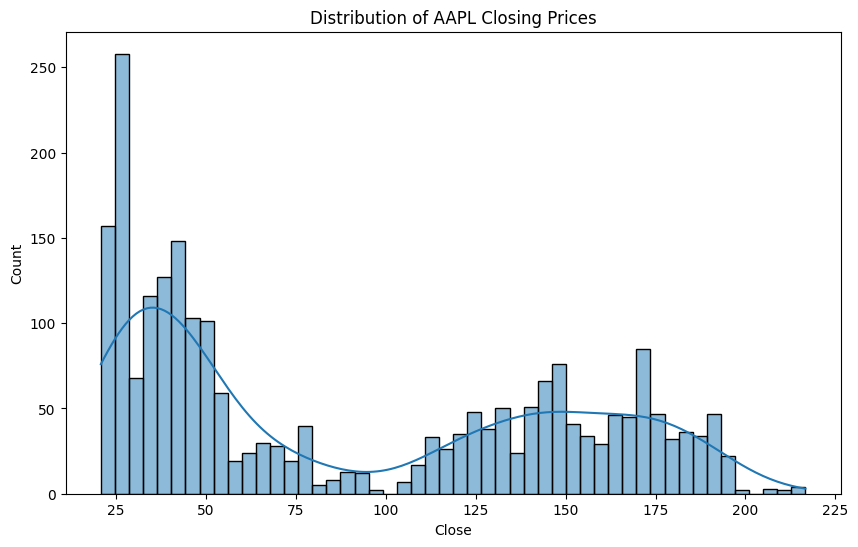

<Figure size 1400x700 with 0 Axes>

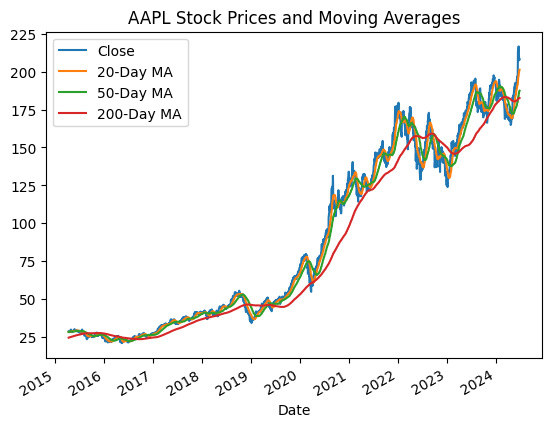

<Figure size 1400x700 with 0 Axes>

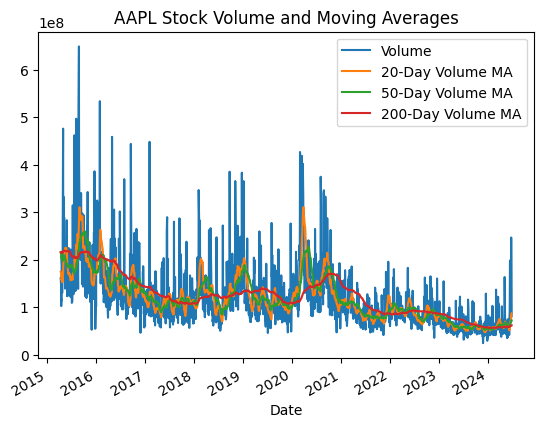

In [ ]:
# Correlation Analysis
# Plot the EDA visuals
def plot_eda(preprocessed_data, ticker):
    # Extract data for the given ticker
    df = preprocessed_data[ticker]

    # Correlation Matrix
    plt.figure(figsize=(12, 8))
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title(f'Correlation Matrix for {ticker} Features')
    plt.show()

    # Distribution Plot
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Close'], bins=50, kde=True)
    plt.title(f'Distribution of {ticker} Closing Prices')

    # Time Series Analysis
    plt.figure(figsize=(14, 7))
    df[['Close', '20-Day MA', '50-Day MA', '200-Day MA']].plot()
    plt.title(f'{ticker} Stock Prices and Moving Averages')
    plt.show()

    # Volume Analysis
    plt.figure(figsize=(14, 7))
    df[['Volume', '20-Day Volume MA', '50-Day Volume MA', '200-Day Volume MA']].plot()
    plt.title(f'{ticker} Stock Volume and Moving Averages')
    plt.show()

plot_eda(preprocessed_data, 'AAPL')

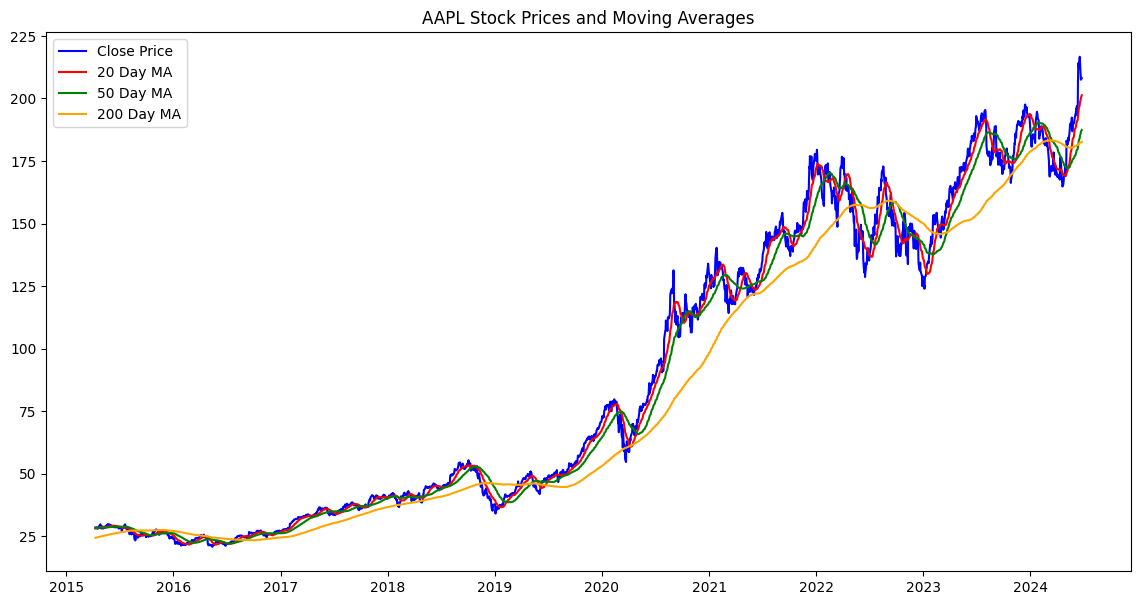

In [ ]:
# MA vs Price Change CrossOver
def plot_prices_and_moving_averages(df, ticker):
  plt.figure(figsize=(14,7))
  plt.plot(df['Close'], label='Close Price', color='blue')
  plt.plot(df['20-Day MA'], label='20 Day MA', color='red')
  plt.plot(df['50-Day MA'], label='50 Day MA', color='green')
  plt.plot(df['200-Day MA'], label='200 Day MA', color='orange')
  plt.title(f'{ticker} Stock Prices and Moving Averages')
  plt.legend()
  plt.show()

plot_prices_and_moving_averages(preprocessed_data['AAPL'], 'AAPL')

In [ ]:
# High Volume Anomalies
def identify_high_volume_anomalies(df, ticker, threshold=2):
  volume_mean = df['Volume'].mean()
  volume_std = df['Volume'].std()
  high_volume_threshold = volume_mean + (threshold * volume_std)
  df['High Volume Anomaly'] = df['Volume'] > high_volume_threshold

  # Return and print the high-volume anomalies
  anomalies = df[df['High Volume Anomaly']]
  print(f"High-Volume Anomalies for {ticker}:")
  print(anomalies[['Volume', 'High Volume Anomaly']])

  return df

# Apply the function to the stocks data
tickers_to_check = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'AMZN']

for ticker in tickers_to_check:
    identify_high_volume_anomalies(all_stock_data[ticker], ticker)

High-Volume Anomalies for AAPL:
                              Volume  High Volume Anomaly
Date                                                     
2014-07-23 00:00:00-04:00  371672000                 True
2014-08-19 00:00:00-04:00  277596000                 True
2014-08-28 00:00:00-04:00  273840000                 True
2014-09-03 00:00:00-04:00  501684000                 True
2014-09-04 00:00:00-04:00  342872000                 True
...                              ...                  ...
2020-08-03 00:00:00-04:00  308151200                 True
2020-08-21 00:00:00-04:00  338054800                 True
2020-08-24 00:00:00-04:00  345937600                 True
2020-09-04 00:00:00-04:00  332607200                 True
2020-09-18 00:00:00-04:00  287104900                 True

[118 rows x 2 columns]
High-Volume Anomalies for MSFT:
                              Volume  High Volume Anomaly
Date                                                     
2014-06-27 00:00:00-04:00   74640000      

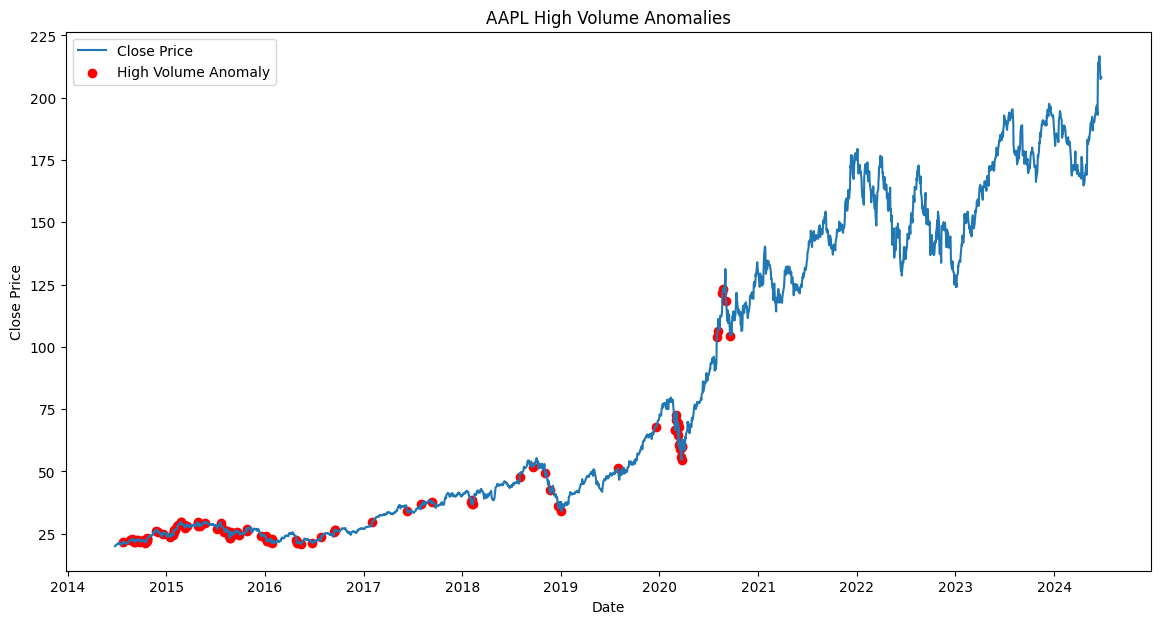

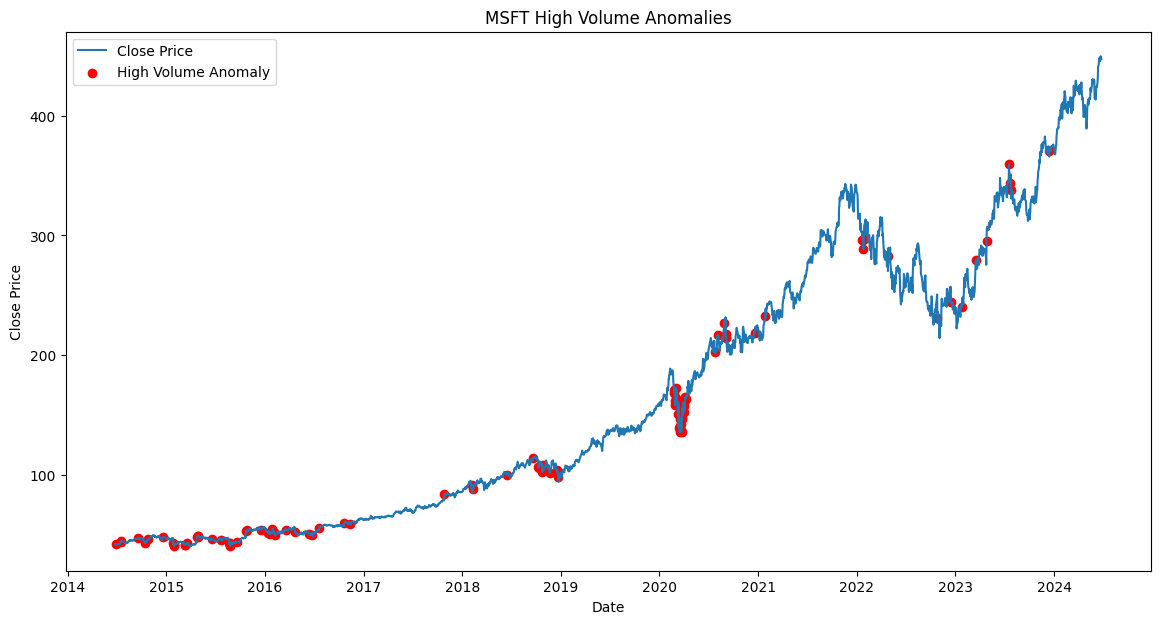

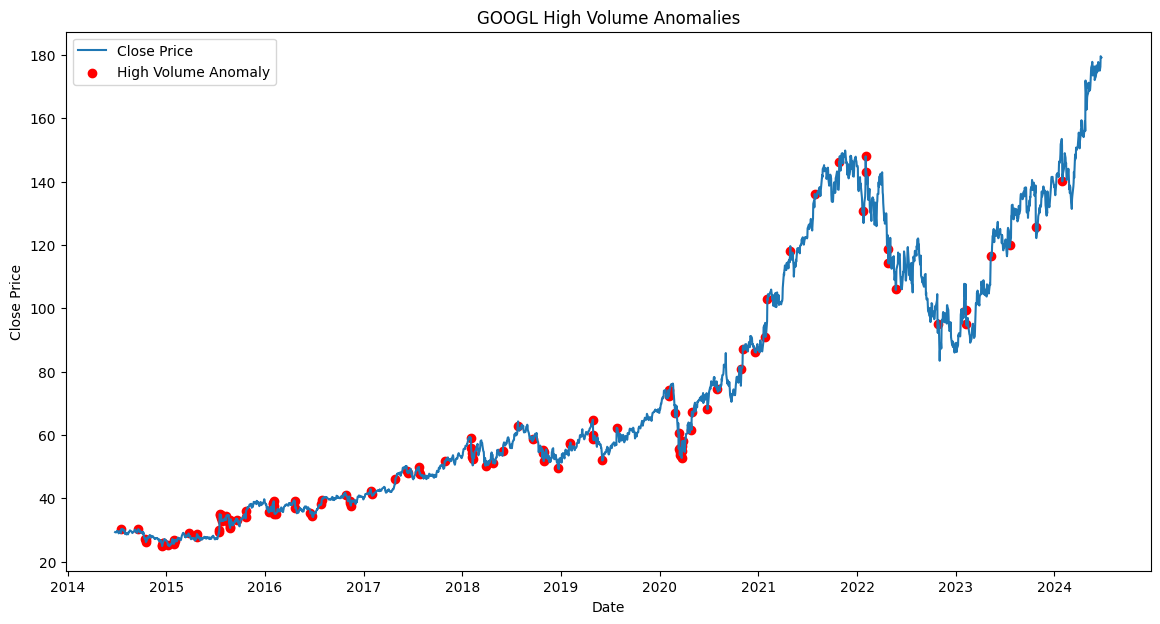

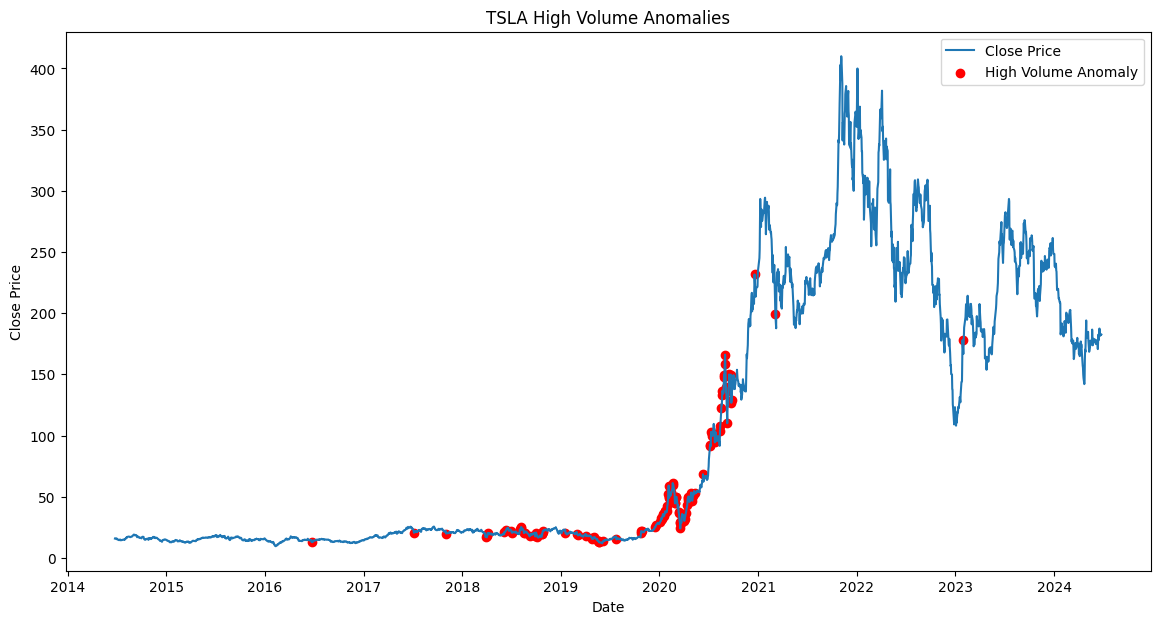

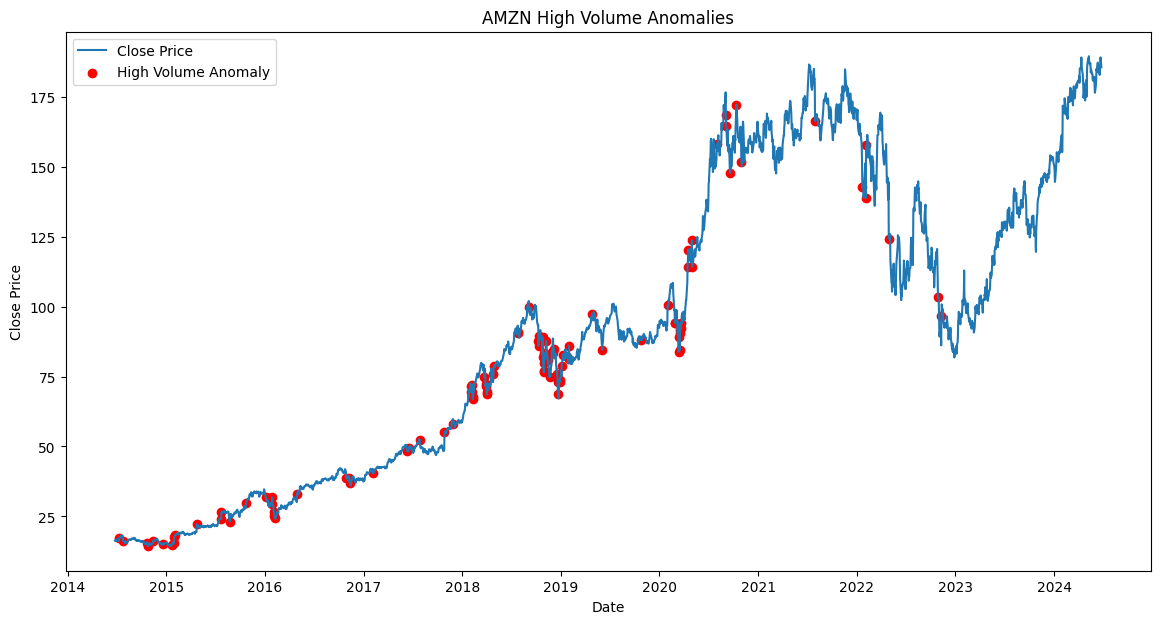

In [ ]:
def plot_high_volume_anomalies(df, ticker):
  plt.figure(figsize=(14, 7))

  plt.plot(df.index, df['Close'], label='Close Price')
  plt.scatter(df.index[df['High Volume Anomaly']],
              df['Close'][df['High Volume Anomaly']],
              color='red', label='High Volume Anomaly', marker='o')

  plt.title(f'{ticker} High Volume Anomalies')
  plt.xlabel('Date')
  plt.ylabel('Close Price')
  plt.legend()
  plt.show()

# Apply the function to visualize
for ticker in tickers_to_check:
    plot_high_volume_anomalies(all_stock_data[ticker], ticker)

In [ ]:
# Additonal Data Cleaning
